In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [49]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IN_DIR = Path("./outputs")       # per-run CSV들이 있는 폴더
OUT_DIR = Path("./outputs/agg")  # 집계/플롯 저장 폴더
OUT_DIR.mkdir(parents=True, exist_ok=True)

pattern = "*.csv"
files = sorted(IN_DIR.glob(pattern))
len(files)

72

In [50]:
dfs = []
for fp in files:
    df = pd.read_csv(fp)

    if not {"dataset", "method", "mode", "seed"}.issubset(df.columns):
        m = re.match(r"(.+?)__(.+?)__(.+?)__run(.+?)__(.+?)__seed(\d+)\.csv", fp.name)
        if m:
            df.insert(0, "dataset", m.group(1))
            df.insert(1, "method", m.group(2))
            df.insert(2, "mode", m.group(3))
            df.insert(3, "run", m.group(4))
            df.insert(4, "sample", m.group(5))
            df.insert(5, "seed", int(m.group(6)))
        else:
            raise ValueError(f"Missing meta columns and cannot parse filename: {fp.name}")

    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def aggregate_all_methods(agg_df: pd.DataFrame, mode='tatr', dataset='rossmann'):
    # 1. Dataset과 Mode만 필터링 (Method는 모두 포함)
    filtered = agg_df[(agg_df['dataset'] == dataset) & (agg_df['mode'] == mode)]
    
    # 2. X축 컬럼 설정 (mode에 따라 변경)
    x_col = 'aug_ratio' if mode == 'tatr' else 'syn_ratio'
    
    # 3. 필요한 컬럼만 추출
    # method를 포함하여 그룹핑해야 함
    group_cols = ['method', x_col]
    metric_cols = ['mse', 'mae', 'mape']
    
    # 4. 집계 (Mean, Std)
    # groupby에 'method'가 추가됨 -> method별, ratio별 통계가 나옴
    agg_result = filtered.groupby(group_cols)[metric_cols].agg(['mean', 'std']).reset_index()
    
    return agg_result, x_col

# 사용 예시
DATASET = 'rossmann_subsampled'
MODE = 'tatr'  # 혹은 'tmtr'
final_df, x_axis_name = aggregate_all_methods(all_df, mode=MODE, dataset=DATASET)

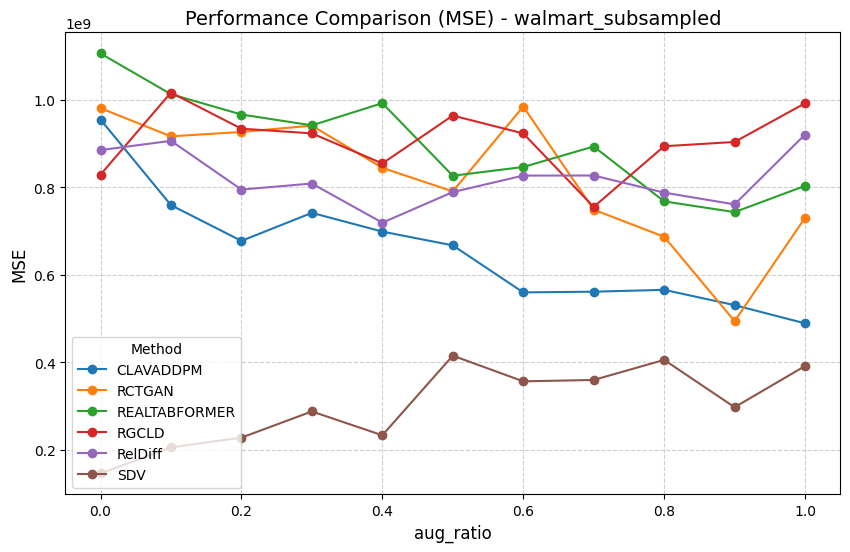

In [ ]:
def plot_performance(agg_result, x_col, metric='mse', title_suffix=''):
    """
    agg_result: 위에서 집계한 DataFrame
    x_col: 'aug_ratio' 또는 'syn_ratio'
    metric: 그릴 지표 ('mse', 'mae', 'mape')
    """
    
    plt.figure(figsize=(10, 6))
    
    # 유니크한 method 리스트 추출
    methods = agg_result['method'].unique()
    
    # 각 Method별로 반복하며 그리기
    for method in methods:
        # 해당 method의 데이터만 추출
        subset = agg_result[agg_result['method'] == method]
        
        # X축: ratio, Y축: 평균값
        x = subset[x_col]
        y_mean = subset[metric]['mean']
        y_std = subset[metric]['std']
        
        # 메인 선 그래프 (평균)
        line, = plt.plot(x, y_mean, label=method, marker='o')
        
        # # 오차 범위 (표준편차) 음영 처리
        # plt.fill_between(
        #     x, 
        #     y_mean - y_std, 
        #     y_mean + y_std, 
        #     color=line.get_color(), 
        #     alpha=0.2  # 투명도 조절
        # )

    # 그래프 스타일 설정
    plt.title(f'Performance Comparison ({metric.upper()}) - {title_suffix}', fontsize=14)
    plt.xlabel(x_col, fontsize=12)
    plt.ylabel(metric.upper(), fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Method')
    
    plt.show()

final_df, x_axis_name = aggregate_all_methods(all_df, mode=MODE, dataset=DATASET)

# 2. 그래프 그리기 (MSE 기준)
plot_performance(final_df, x_axis_name, metric='mse', title_suffix=DATASET)

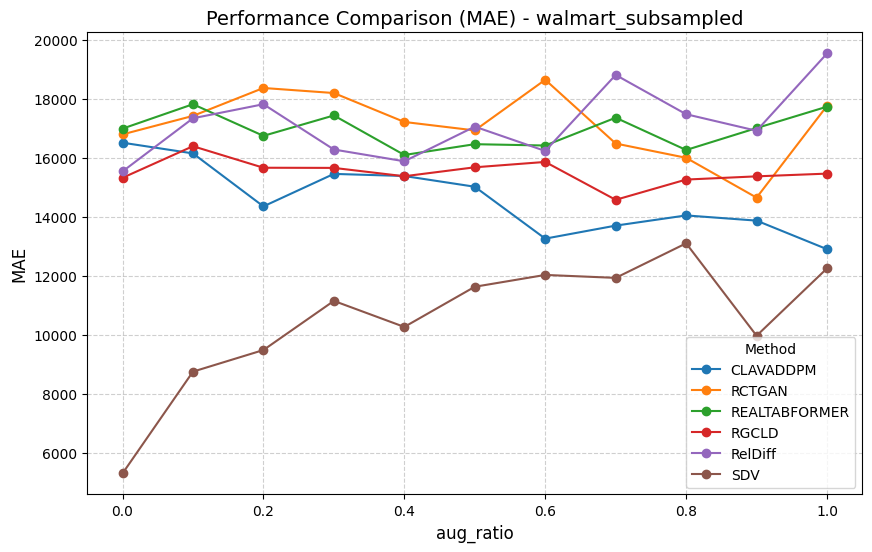

In [53]:
DATASET = 'walmart_subsampled'
MODE = 'tatr'  # 혹은 'tmtr'
final_df, x_axis_name = aggregate_all_methods(all_df, mode=MODE, dataset=DATASET)
plot_performance(final_df, x_axis_name, metric='mae', title_suffix=DATASET)

In [58]:
final_df[final_df['aug_ratio']==0.0]

method aug_ratio           mse                mae       \
                                     mean  std          mean  std   
0       CLAVADDPM       0.0  9.552407e+08  0.0  16518.971313  0.0   
11         RCTGAN       0.0  9.814124e+08  0.0  16800.158190  0.0   
22  REALTABFORMER       0.0  1.106534e+09  0.0  16994.830456  0.0   
33          RGCLD       0.0  8.292508e+08  0.0  15328.641535  0.0   
44        RelDiff       0.0  8.853652e+08  0.0  15543.921171  0.0   
55            SDV       0.0  1.453202e+08  0.0   5310.374070  0.0   

            mape       
            mean  std  
0   4.799837e+00  0.0  
11  8.201956e+00  0.0  
22  4.796827e+00  0.0  
33  4.521222e+00  0.0  
44  5.841716e+00  0.0  
55  8.126159e+15  0.0